# Importing

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import scipy.constants
# for delta plot
import pylab as pyl

In [2]:
import os
import sys
import inspect
currentdir = os.getcwd()
parentdir = os.path.dirname(currentdir)

#------------ FILES PARENTDIR ------------#
sys.path.insert(0, parentdir)
from NFW_class import NFW_profile, r1
from Isothermal_paper_2206 import stitchSIDMcore, deltaSqare, findTwoDeltaMinimum
# helpfull functions and constans
import Config as cfg

#------------ FILES CURRENTDIR ------------#
sys.path.insert(0, currentdir)

# Creating NFW Class

In [3]:
NFW_profile = NFW_profile(cfg.M_vir, cfg.const_c)

In [4]:
#time
time_evolution = 5 * cfg.Gyr # [s]

In [5]:
r_s = NFW_profile.r_s
rounded_r_s = cfg.rounded_number(r_s, 3)

rho_s = NFW_profile.rho_s
rounded_rho_s = cfg.rounded_number(rho_s, 3)
print(f"rho_s = {rounded_rho_s} [M_solar / kpc^3], r_s = {rounded_r_s} [kpc]")

#-------------------------------------------------------------------------------------------
# new way to get r1
r_1 = r1(NFW_profile,sigmamx=cfg.sigma_m,tage=(cfg.time_evolution/cfg.Gyr))
print(f"r_1 = {r_1} [kpc]")

rho_s = 17200000.0 [M_solar / kpc^3], r_s = 6.32 [kpc]
r_1 = 4.90267137751015 [kpc]


# Isothermal

In [6]:
# SIDM = stitchSIDMcore(r_1, NFW_profile)

# Isotherma: low dense
SIDM_LoDens = findTwoDeltaMinimum(r_1, NFW_profile)[0]
# Isothermal: high dense
SIDM_HiDens = findTwoDeltaMinimum(r_1, NFW_profile)[1]

In [7]:
# rhodm0 -> central DM density. Isothermal density
print(f"SIDM_LoDens, rhodm0:  {'{:.2E}'.format(SIDM_LoDens[0])} [M_sun / kpc^3]. ")
print(f"SIDM_HiDens, rhodm0:  {'{:.2E}'.format(SIDM_HiDens[0])} [M_sun / kpc^3]. ")

# sigma0 -> central DM velocity dispersion. Isothermal velocity dispersion (nu, sigma)
print(f"SIDM_LoDens, sigma0: {'{:.1f}'.format(SIDM_LoDens[1])} [km/s]")
print(f"SIDM_HiDens, sigma0: {'{:.1f}'.format(SIDM_HiDens[1])} [km/s]")

# rho
# SIDM_LoDens[2]
# Vc
# SIDM_LoDens[3]
# r
# SIDM_LoDens[4]

SIDM_LoDens, rhodm0:  5.84E+07 [M_sun / kpc^3]. 
SIDM_HiDens, rhodm0:  1.72E+11 [M_sun / kpc^3]. 
SIDM_LoDens, sigma0: 54.5 [km/s]
SIDM_HiDens, sigma0: 62.5 [km/s]


# Density profile

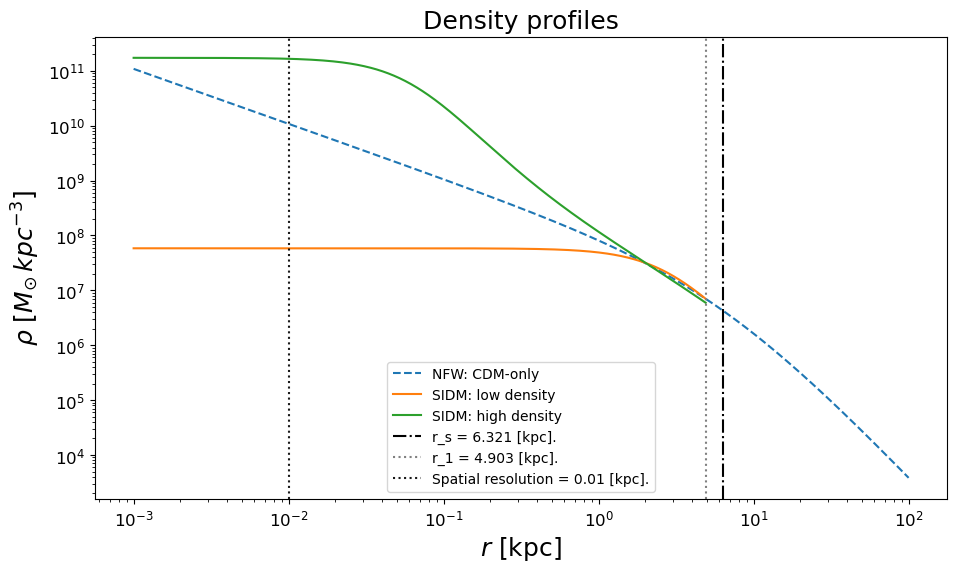

In [8]:
plot_r = np.logspace(-3.0, 2.0, num=300)
#------------------------------ NFW PROFILE ------------------------------#
# NFW profile: density profile
plot_rho_NFW = NFW_profile.rho(plot_r)

#------------------------------ ISOTHERMAL ------------------------------#
# Isothermal - low dense
r_LoDens = SIDM_LoDens[4]
rho_LoDens = SIDM_LoDens[2]
# Isothermal - high dense
r_HiDens = SIDM_HiDens[4]
rho_HiDens = SIDM_HiDens[2]

#------------------------------ LINES ------------------------------#
r_s = NFW_profile.r_s
r_1 = r1(NFW_profile,sigmamx=cfg.sigma_m,tage=(cfg.time_evolution/cfg.Gyr))
Rres = 0.01

#------------------------------ PLOTTING ------------------------------#
fig, ax = plt.subplots(figsize=(11.0, 6.0))
ax.plot(plot_r, plot_rho_NFW, '--',label="NFW: CDM-only")
ax.plot(r_LoDens, rho_LoDens,label="SIDM: low density")
ax.plot(r_HiDens, rho_HiDens,label="SIDM: high density")

# lines
plt.axvline(x=r_s, color='black', linestyle = 'dashdot',
                    label=f'r_s = {"{:.3f}".format(r_s)} [kpc].')
plt.axvline(x=r_1, color='grey', linestyle = 'dotted',
                    label=f'r_1 = {"{:.3f}".format(r_1)} [kpc].')
plt.axvline(x=Rres, color='black', linestyle = 'dotted', alpha=0.9, 
                    label=f'Spatial resolution = {"{:.2f}".format(Rres)} [kpc].')
# log scale
ax.set_xscale('log')
ax.set_yscale('log')
# describe NFW profile
plt.ylabel(r"$\rho \, \, [M_{\odot} \, kpc^{-3}]$", fontsize=18)
plt.xlabel(r"$r$ [kpc]", fontsize=18)
plt.title("Density profiles", fontsize=18)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.legend()
plt.show()

# Circular velocity

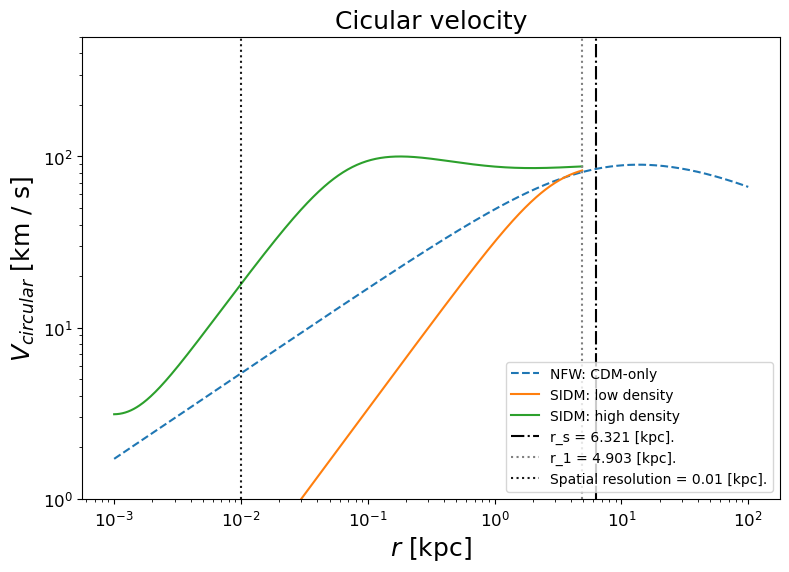

In [9]:
plot_r = np.logspace(-3.0, 2.0, num=300)
#------------------------------ NFW PROFILE ------------------------------#
# NFW profile: circular velocity
Vcirc_NFW = NFW_profile.Vcirc(plot_r) #[kpc/Gyr]

Vcirc_NFW_SI = []
for i in range(0, len(plot_r)):
    Vcirc_SI = Vcirc_NFW[i] * cfg.kpc_SI / cfg.Gyr # [m/s]
    # append
    Vcirc_NFW_SI.append(Vcirc_SI * 10**(-3)) # [km / s]

#------------------------------ ISOTHERMAL ------------------------------#
# Isothermal - low dense
r_LoDens = SIDM_LoDens[4]
Vcirc_LoDens = SIDM_LoDens[3]
# Isothermal - high dense
r_HiDens = SIDM_HiDens[4]
Vcirc_HiDens = SIDM_HiDens[3]

#------------------------------ LINES ------------------------------#
r_s = NFW_profile.r_s
r_1 = r1(NFW_profile,sigmamx=cfg.sigma_m,tage=(cfg.time_evolution/cfg.Gyr))
Rres = 0.01


#------------------------------ PLOTTING ------------------------------#
fig, ax = plt.subplots(figsize=(9.0, 6.0))
ax.plot(plot_r, Vcirc_NFW_SI, '--',label="NFW: CDM-only")
ax.plot(r_LoDens, Vcirc_LoDens,label="SIDM: low density")
ax.plot(r_HiDens, Vcirc_HiDens,label="SIDM: high density")

# lines
plt.axvline(x=r_s, color='black', linestyle = 'dashdot',
                    label=f'r_s = {"{:.3f}".format(r_s)} [kpc].')
plt.axvline(x=r_1, color='grey', linestyle = 'dotted',
                    label=f'r_1 = {"{:.3f}".format(r_1)} [kpc].')
plt.axvline(x=Rres, color='black', linestyle = 'dotted', alpha=0.9,
                    label=f'Spatial resolution = {"{:.2f}".format(Rres)} [kpc].')
# log scale 
ax.set_xscale('log')
ax.set_yscale('log')
# describe NFW profile
plt.ylim(10**0, 5*10**2)
plt.ylabel(r"$V_{circular}$ [km / s]", fontsize=18)
plt.xlabel(r"$r$ [kpc]", fontsize=18)
plt.title("Cicular velocity", fontsize=18)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.legend()
plt.show()

# Delta and search for best parameters

In [10]:
# vales of our parameters
rho_dm0 = np.logspace(7., 14., 100)

sigma_beg = 0.5 * NFW_profile.sigma_accurate(r_1) * cfg.kpc_SI / cfg.Gyr * 10**(-3) # [km/s]
sigma_end = 2 * NFW_profile.sigma_accurate(r_1) * cfg.kpc_SI / cfg.Gyr * 10**(-3) # [km/s]
sigma_0 = np.logspace(np.log10(sigma_beg), np.log10(sigma_end), 100)
# set r1
r_1 = r1(NFW_profile,sigmamx=cfg.sigma_m,tage=(cfg.time_evolution/cfg.Gyr))
# values which we have to use: constants
# rhob0 = NFW_profile.rho_s
# r_s = NFW_profile.r_s
rhob0 = 1e-6
r_s = 100.

rhoCDM1 = NFW_profile.rho(r_1)
MCDM1 = NFW_profile.Mass(r_1)
# the radiuses of using isothermal profile
r = np.logspace(-3.,np.log10(r_1),500)

In [11]:
# printing important values - which we will present on plot
print(f"rho value at r1: {'{:.2E}'.format(rhoCDM1)} [M_sun / kpc^3]")
rhoCDMRres = NFW_profile.rho(0.01)
print(f"rho value at spatial resolution (0.01 kpc): {'{:.2E}'.format(rhoCDMRres)} [M_sun / kpc^3]. ")

# velocity dispersion
nu_at_r1 = NFW_profile.sigma_accurate(r_1) * cfg.kpc_SI / cfg.Gyr * 10**(-3) # [km/s]
print(f"Velocity dispersion (nu) at r1: {'{:.1f}'.format(nu_at_r1)} [km/s]")

# circular velocity
Vcirc_at_r1 = NFW_profile.Vcirc(r_1) * cfg.kpc_SI / cfg.Gyr * 10**(-3) # [km/s]
print(f"Circular velocity (nu) at r1: {'{:.1f}'.format(Vcirc_at_r1)} [km/s]")

rho value at r1: 7.02E+06 [M_sun / kpc^3]
rho value at spatial resolution (0.01 kpc): 1.08E+10 [M_sun / kpc^3]. 
Velocity dispersion (nu) at r1: 59.1 [km/s]
Circular velocity (nu) at r1: 81.0 [km/s]


In [12]:
def cal_delta(rho_dm0, sigma_0):
    """
    calculate the deltaSqare, which was appear in file Isothermal_paper_2206.py
    """
    log_rho_dm0 = np.log10(rho_dm0)
    log_sigma_0 = np.log10(sigma_0)
    p_list = [log_rho_dm0, log_sigma_0]
    p = np.array(p_list)
    
    return deltaSqare(p, rhob0, r_s, rhoCDM1, MCDM1, r)

In [13]:
np.log10(10)

1.0

In [14]:
#Prepare Z axis (logdelta)
x = sigma_0 # sigma_0 = np.logspace(np.log10(30), np.log10(118), 500)
y = rho_dm0 # rho_dm0 = np.logspace(7., 14., 500)
X,Y = pyl.meshgrid(x, y) # grid of point

#creating the values
Z = []
for yy in y:
    zy = []
    for xx in x:
        # calculate log delta
        log_delta = np.log10(cal_delta(yy,xx)) * 1/2
        zy.append(log_delta)
    
    Z.append(zy)

In [15]:
# min(min(Z))

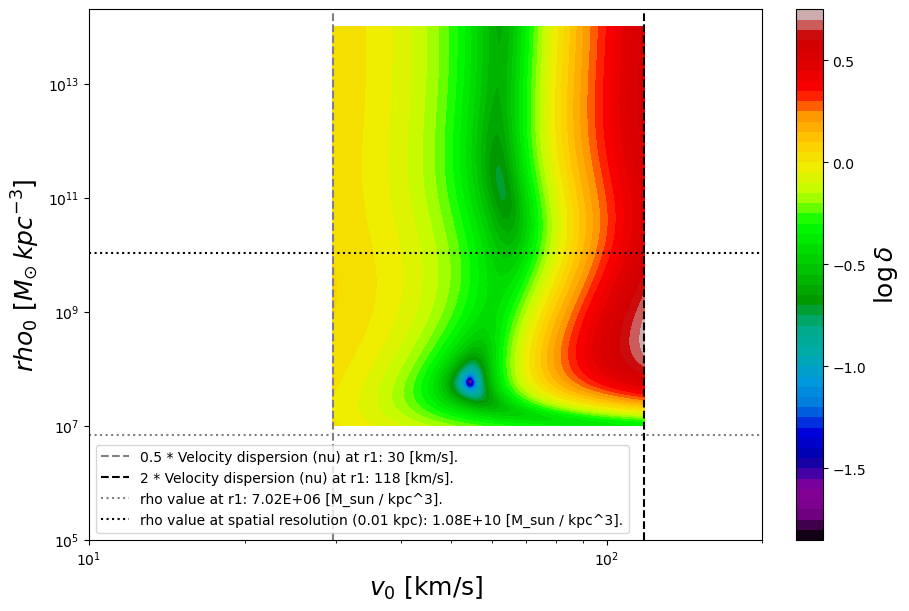

In [16]:
origin = 'lower'

fig, ax2 = plt.subplots(constrained_layout=True, figsize=(9.0, 6.0))

# Z_to_show = np.arange(min(min(Z)),max(max(Z)),.1) #Adjust the .001 to get finer gradient
# Z_to_show = [-2., -1.5, -1., -0.5, 0.]

CS = ax2.contourf(X, Y, Z,  levels=50, cmap='nipy_spectral')
# CS = ax2.contourf(X, Y, Z,  levels=40)

# Note that in the following, we explicitly pass in a subset of the contour
# levels used for the filled contours.  Alternatively, we could pass in
# additional levels to provide extra resolution, or leave out the *levels*
# keyword argument to use all of the original levels.

# CS2 = ax.contour(CS, levels=CS.levels[::2], colors='r', origin=origin)
# CS2 = ax.contour(CS, colors='r', origin=origin)

plt.ylim(10**5, 2*10**14)
plt.xlim(10**1, 2*10**2)
ax2.set_xscale('log')
ax2.set_yscale('log')
# ax2.set_title('$\log \delta$', fontsize=18 )
ax2.set_xlabel(r"$v_{0}$ [km/s]", fontsize=18)
ax2.set_ylabel(r"$rho_{0} \, \, [M_{\odot} \, kpc^{-3}]$", fontsize=18)

# lines
plt.axvline(x=0.5*nu_at_r1, color='grey', linestyle = '--',
                    label=f'0.5 * Velocity dispersion (nu) at r1: {"{:.0f}".format(0.5*nu_at_r1)} [km/s].')
plt.axvline(x=2*nu_at_r1, color='black', linestyle = '--',
                    label=f'2 * Velocity dispersion (nu) at r1: {"{:.0f}".format(2*nu_at_r1)} [km/s].')
plt.axhline(y=rhoCDM1, color='grey', linestyle = ':',
                    label=f'rho value at r1: {"{:.2E}".format(rhoCDM1)} [M_sun / kpc^3].')
plt.axhline(y=rhoCDMRres, color='black', linestyle = ':',
                    label=f'rho value at spatial resolution (0.01 kpc): {"{:.2E}".format(rhoCDMRres)} [M_sun / kpc^3].')


# Make a colorbar for the ContourSet returned by the contourf call.
cbar = fig.colorbar(CS, ticks=mticker.MaxNLocator(6))
cbar.ax.set_ylabel('$\log \delta$', fontsize=18)
# Add the contour line levels to the colorbar
# cbar.add_lines(CS2)

ax2.legend(loc='lower left')

In [17]:
# Way to search the two saperetly minimum
r_1 = r1(NFW_profile,sigmamx=cfg.sigma_m,tage=(cfg.time_evolution/cfg.Gyr))
twoMinimumData = findTwoDeltaMinimum(r_1, NFW_profile)

# case: high density
rhodm0_LoDens = twoMinimumData[0][0] #[M_sun/kpc^3]
sigma0_LoDens = twoMinimumData[0][1] #[kpc/Gyr]
sigma0_LoDens_km_s = sigma0_LoDens * cfg.kpc_SI / cfg.Gyr * 10**(-3) # [km/s]
print('case: low density, best selection of parameters')
print(f"central DM density {'{:.2E}'.format(rhodm0_LoDens)} [M_sun/kpc^3]")
print(f"central DM velocity dispersion {'{:.1f}'.format(sigma0_LoDens_km_s)} [km/s]")
print()

# case: high density
rhodm0_HiDens = twoMinimumData[1][0] #[M_sun/kpc^3]
sigma0_HiDens = twoMinimumData[1][1] #[kpc/Gyr]
sigma0_HiDens_km_s =  sigma0_HiDens * cfg.kpc_SI / cfg.Gyr * 10**(-3) # [km/s]
print('case: high density, best selection of parameters')
print(f"central DM density {'{:.2E}'.format(rhodm0_HiDens)} [M_sun/kpc^3]")
print(f"central DM velocity dispersion {'{:.1f}'.format(sigma0_HiDens_km_s)} [km/s]")

case: low density, best selection of parameters
central DM density 5.84E+07 [M_sun/kpc^3]
central DM velocity dispersion 53.3 [km/s]

case: high density, best selection of parameters
central DM density 1.72E+11 [M_sun/kpc^3]
central DM velocity dispersion 61.1 [km/s]


# Velocity desparsion 

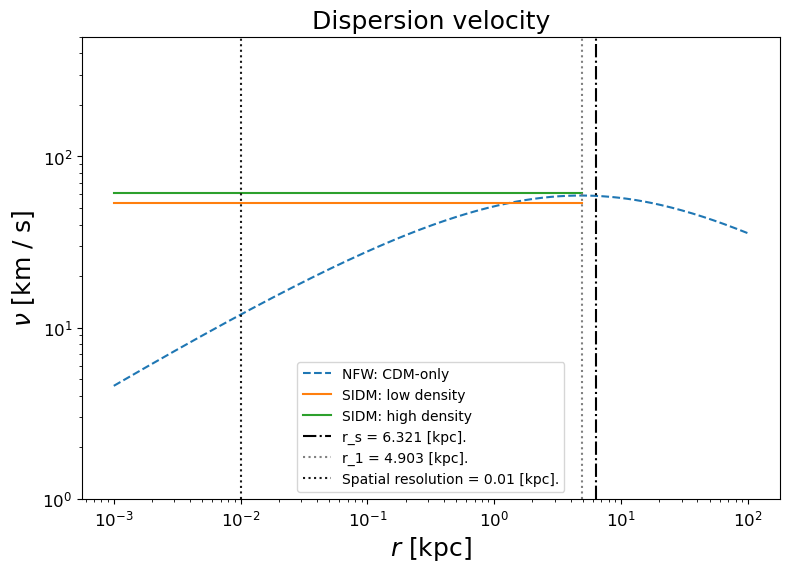

In [18]:
plot_r = np.logspace(-3.0, 2.0, num=300)
#------------------------------ NFW PROFILE ------------------------------#
# NFW profile: dispersion velosity
Vdis_NFW = NFW_profile.sigma_accurate(plot_r) #[kpc/Gyr]

Vdis_NFW_km_s = []
for i in range(0, len(plot_r)):
    Vdis_SI = Vdis_NFW[i] * cfg.kpc_SI / cfg.Gyr # [m/s]
    # append
    Vdis_NFW_km_s.append(Vdis_SI * 10**(-3)) # [km/s]

#------------------------------ ISOTHERMAL ------------------------------#
# Isothermal - low dense
r_LoDens = SIDM_LoDens[4]
sigma0_LoDens = SIDM_LoDens[1] #[kpc/Gyr]
sigma0_LoDens_km_s = sigma0_LoDens * cfg.kpc_SI / cfg.Gyr * 10**(-3) # [km/s]
sigma0_LoDens_list = [sigma0_LoDens_km_s] * len(r_LoDens)
# Isothermal - high dense dense
r_HiDens = SIDM_HiDens[4]
sigma0_HiDens = SIDM_HiDens[1] #[kpc/Gyr]
sigma0_HiDens_km_s = sigma0_HiDens * cfg.kpc_SI / cfg.Gyr * 10**(-3) # [km/s]
sigma0_HiDens_list = [sigma0_HiDens_km_s] * len(r_HiDens)

#------------------------------ LINES ------------------------------#
r_s = NFW_profile.r_s
r_1 = r1(NFW_profile,sigmamx=cfg.sigma_m,tage=(cfg.time_evolution/cfg.Gyr))
Rres = 0.01

#------------------------------ PLOTTING ------------------------------#
fig, ax = plt.subplots(figsize=(9.0, 6.0))
ax.plot(plot_r, Vdis_NFW_km_s, '--', label="NFW: CDM-only")
ax.plot(r_LoDens, sigma0_LoDens_list, label="SIDM: low density")
ax.plot(r_HiDens, sigma0_HiDens_list, label="SIDM: high density")

# lines
plt.axvline(x=r_s, color='black', linestyle = 'dashdot',
                    label=f'r_s = {"{:.3f}".format(r_s)} [kpc].')
plt.axvline(x=r_1, color='grey', linestyle = 'dotted',
                    label=f'r_1 = {"{:.3f}".format(r_1)} [kpc].')
plt.axvline(x=Rres, color='black', linestyle = 'dotted', alpha=0.9,
                    label=f'Spatial resolution = {"{:.2f}".format(Rres)} [kpc].')
# log scale
ax.set_xscale('log')
ax.set_yscale('log')
# describe NFW profile
plt.ylim(10**0, 5*10**2)
plt.ylabel(r"$\nu$ [km / s]", fontsize=18)
plt.xlabel(r"$r$ [kpc]", fontsize=18)
plt.title("Dispersion velocity", fontsize=18)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.legend()
plt.show()

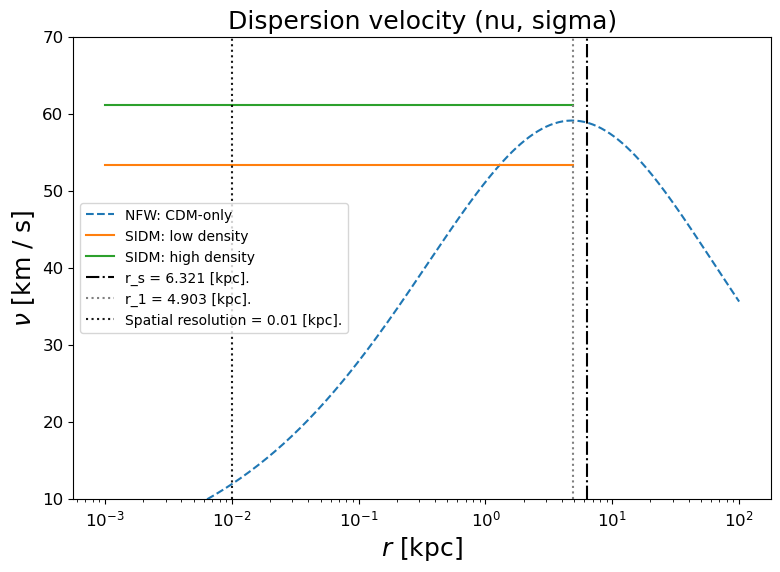

In [19]:
plot_r = np.logspace(-3.0, 2.0, num=300)
#------------------------------ NFW PROFILE ------------------------------#
# NFW profile: dispersion velosity
Vdis_NFW = NFW_profile.sigma_accurate(plot_r) #[kpc/Gyr]

Vdis_NFW_km_s = []
for i in range(0, len(plot_r)):
    Vdis_SI = Vdis_NFW[i] * cfg.kpc_SI / cfg.Gyr # [m/s]
    # append
    Vdis_NFW_km_s.append(Vdis_SI * 10**(-3)) # [km/s]

#------------------------------ ISOTHERMAL ------------------------------#
# Isothermal - low dense
r_LoDens = SIDM_LoDens[4]
sigma0_LoDens = SIDM_LoDens[1] #[kpc/Gyr]
sigma0_LoDens_km_s = sigma0_LoDens * cfg.kpc_SI / cfg.Gyr * 10**(-3) # [km/s]
sigma0_LoDens_list = [sigma0_LoDens_km_s] * len(r_LoDens)
# Isothermal - high dense dense
r_HiDens = SIDM_HiDens[4]
sigma0_HiDens = SIDM_HiDens[1] #[kpc/Gyr]
sigma0_HiDens_km_s = sigma0_HiDens * cfg.kpc_SI / cfg.Gyr * 10**(-3) # [km/s]
sigma0_HiDens_list = [sigma0_HiDens_km_s] * len(r_HiDens)

#------------------------------ LINES ------------------------------#
r_s = NFW_profile.r_s
r_1 = r1(NFW_profile,sigmamx=cfg.sigma_m,tage=(cfg.time_evolution/cfg.Gyr))
Rres = 0.01

#------------------------------ PLOTTING ------------------------------#
fig, ax = plt.subplots(figsize=(9.0, 6.0))
ax.plot(plot_r, Vdis_NFW_km_s, '--', label="NFW: CDM-only")
ax.plot(r_LoDens, sigma0_LoDens_list, label="SIDM: low density")
ax.plot(r_HiDens, sigma0_HiDens_list, label="SIDM: high density")

# lines
plt.axvline(x=r_s, color='black', linestyle = 'dashdot',
                    label=f'r_s = {"{:.3f}".format(r_s)} [kpc].')
plt.axvline(x=r_1, color='grey', linestyle = 'dotted',
                    label=f'r_1 = {"{:.3f}".format(r_1)} [kpc].')
plt.axvline(x=Rres, color='black', linestyle = 'dotted', alpha=0.9,
                    label=f'Spatial resolution = {"{:.2f}".format(Rres)} [kpc].')
# log scale
ax.set_xscale('log')
# ax.set_yscale('log')
# describe NFW profile
plt.ylim(10**1, 7*10**1)
plt.ylabel(r"$\nu$ [km / s]", fontsize=18)
plt.xlabel(r"$r$ [kpc]", fontsize=18)
plt.title("Dispersion velocity (nu, sigma)", fontsize=18)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.legend()
plt.show()